In [2]:
import pandas as pd

df = pd.read_excel("dataset/sales.xlsx")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [3]:
print(df.shape)

(1000, 12)


In [4]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


In [6]:
df.describe()


,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


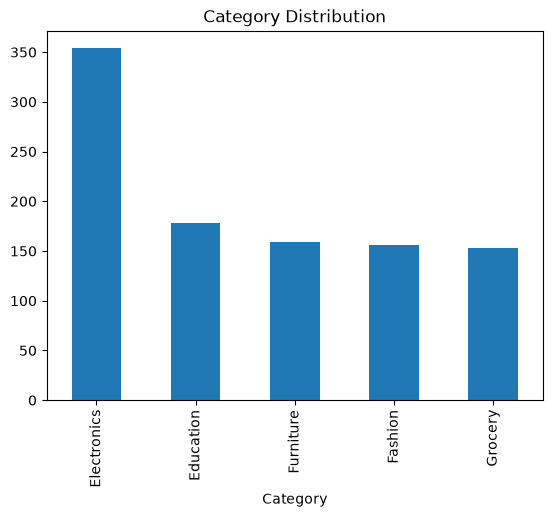

In [7]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")

plt.title("Category Distribution")

plt.show()

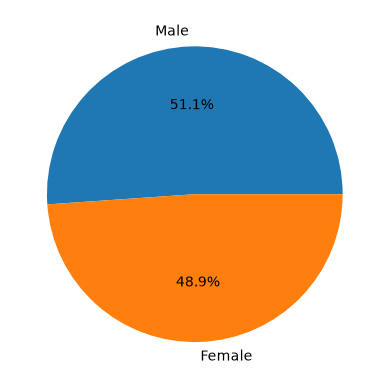

In [8]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

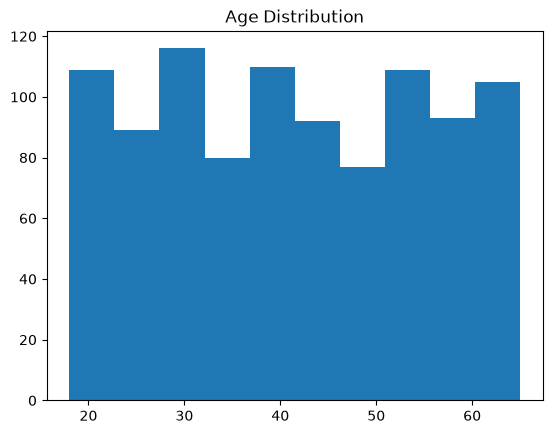

In [9]:
plt.hist(df["Age"])

plt.title("Age Distribution")

plt.show()

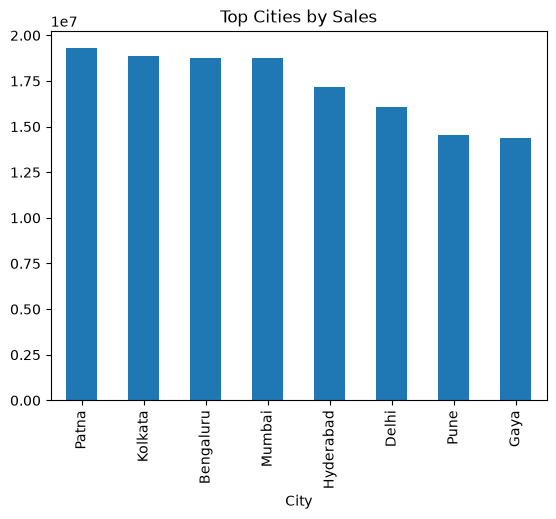

In [10]:
city_sales = df.groupby("City")["Total_Sales"].sum()

city_sales.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top Cities by Sales")

plt.show()

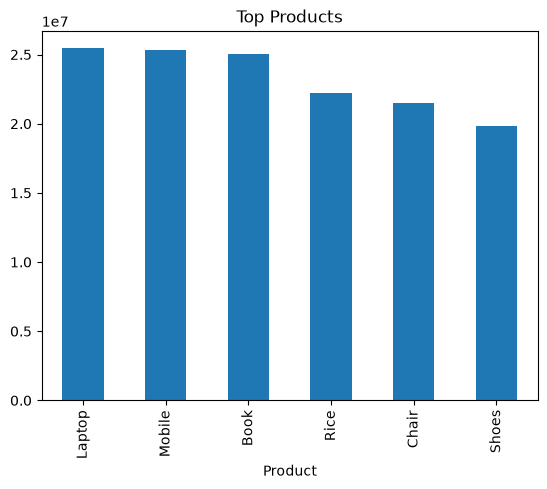

In [11]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

product_sales.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top Products")

plt.show()

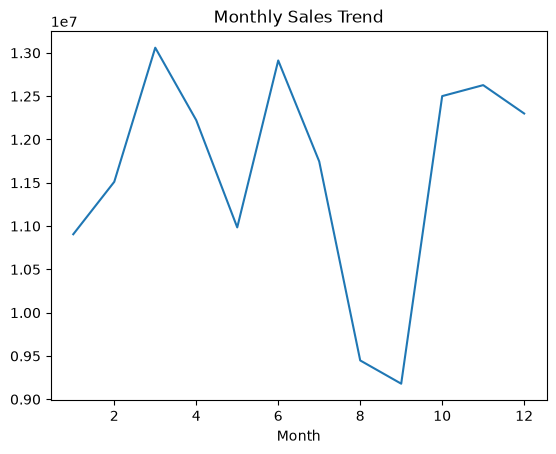

In [12]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"]
)

df["Month"] = df["Order_Date"].dt.month

monthly_sales = df.groupby(
    "Month"
)["Total_Sales"].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

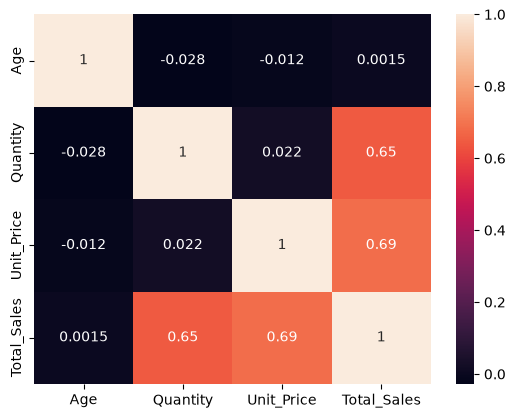

In [13]:
import seaborn as sns

corr = df[
    ["Age",
     "Quantity",
     "Unit_Price",
     "Total_Sales"]
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()